# Predicting Flight Delays with Machine Learning
---

## 🎯 Purpose

The goal is to **predict flight departure delays**.

The dataset contains **111,006 rows** and **29 variables**, covering the **first 6 months of 2022** for flights departing from **two airports**.

## 📊 Variable Descriptions

- `year`: Year – All data is from **2022**.
- `month`: Month – Includes data from **January to June**.
- `day`: Day – Represents days from **1 to 31**.
- `dep_time`: Actual departure time of the flight.
- `sched_dep_time`: Scheduled departure time.
- `dep_delay`: Departure delay duration (in minutes).
- `arr_time`: Actual arrival time.
- `sched_arr_time`: Scheduled arrival time.
- `arr_delay`: Arrival delay duration (in minutes).
- `carrier`: Airline code (abbreviation of the airline).
- `flight`: Flight number.
- `tailnum`: Aircraft tail number.
- `origin`: Departure airport code (only SEA and PDX).
- `dest`: Arrival airport code (covers 97 airports).
- `air_time`: Flight duration (in minutes).
- `distance`: Flight distance (in miles).
- `hour`: Hour (extracted from scheduled departure time).
- `minute`: Minute (extracted from scheduled departure time).
- `airline`: Full airline name.
- `route`: Flight route (e.g., SEA → SFO).
- `temp`: Temperature at departure.
- `dewp`: Dew point – the temperature at which moisture in the air begins to condense.
- `humid`: Humidity percentage.
- `wind_dir`: Wind direction.
- `wind_speed`: Wind speed (average).
- `wind_gust`: Maximum wind speed during a time window.
- `precip`: Precipitation amount.
- `pressure`: Air pressure.
- `visib`: Visibility (in miles or kilometers).


In [ ]:
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
import missingno as msno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from hyperopt import fmin, tpe, hp, Trials
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)
plt.style.use("ggplot")
sns.set_palette(sns.diverging_palette(220, 20))

# Data Cleaning

In [41]:
df = pd.read_csv("data/flights_weather2022.csv")

In [42]:
df.head(3)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,airline,route,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,2022,1,1,1.0,2359,2.0,604.0,618,-14.0,UA,555,N405UA,SEA,IAH,221.0,1874,23,59,United Air Lines Inc.,SEA-IAH,33.0,23.0,66.06,160.0,8.05546,9.270062,0.0,1022.9,10.0
1,2022,1,1,1.0,2250,71.0,242.0,142,60.0,AS,72,N265AK,SEA,FAI,193.0,1533,22,50,Alaska Airlines Inc.,SEA-FAI,32.0,23.0,69.04,170.0,9.20624,10.594357,0.0,1023.4,10.0
2,2022,1,1,10.0,2355,15.0,759.0,730,29.0,AS,270,N274AK,SEA,ATL,261.0,2182,23,55,Alaska Airlines Inc.,SEA-ATL,33.0,23.0,66.06,160.0,8.05546,9.270062,0.0,1022.9,10.0


In [43]:
df.shape

(111006, 29)

In [44]:
len(df.columns)

29

In [45]:
df["month"].value_counts()

month
6    20491
5    19971
4    18741
3    18306
1    17473
2    16024
Name: count, dtype: int64

In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,111006.0,2022.000000,0.000000,2022.00,2022.000000,2022.000000,2022.000000,2022.000000
month,111006.0,3.623264,1.713287,1.00,2.000000,4.000000,5.000000,6.000000
day,111006.0,15.736654,8.723487,1.00,8.000000,16.000000,23.000000,31.000000
dep_time,108566.0,1336.449487,540.664793,1.00,912.000000,1309.000000,1800.000000,2400.000000
sched_dep_time,111006.0,1342.068158,530.610560,2.00,910.000000,1305.000000,1800.000000,2359.000000
dep_delay,108566.0,8.038456,41.687738,-36.00,-5.000000,-2.000000,6.000000,2120.000000
arr_time,108469.0,1467.243636,570.938019,1.00,1055.000000,1520.000000,1917.000000,2400.000000
sched_arr_time,111006.0,1506.330090,546.796862,3.00,1115.000000,1540.000000,1937.000000,2359.000000
arr_delay,108332.0,2.359524,43.088734,-65.00,-14.000000,-5.000000,6.000000,2098.000000
flight,111006.0,433.663856,267.779635,1.00,210.000000,416.000000,644.000000,1100.000000


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111006 entries, 0 to 111005
Data columns (total 29 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            111006 non-null  int64  
 1   month           111006 non-null  int64  
 2   day             111006 non-null  int64  
 3   dep_time        108566 non-null  float64
 4   sched_dep_time  111006 non-null  int64  
 5   dep_delay       108566 non-null  float64
 6   arr_time        108469 non-null  float64
 7   sched_arr_time  111006 non-null  int64  
 8   arr_delay       108332 non-null  float64
 9   carrier         111006 non-null  object 
 10  flight          111006 non-null  int64  
 11  tailnum         110877 non-null  object 
 12  origin          111006 non-null  object 
 13  dest            111006 non-null  object 
 14  air_time        108332 non-null  float64
 15  distance        111006 non-null  int64  
 16  hour            111006 non-null  int64  
 17  minute    

**Numeric Variables**

In [48]:
numeric_df = df.select_dtypes(include=["int64","float64"])
numeric_df.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'flight', 'air_time',
       'distance', 'hour', 'minute', 'temp', 'dewp', 'humid', 'wind_dir',
       'wind_speed', 'wind_gust', 'precip', 'pressure', 'visib'],
      dtype='object')

**Categorical Variables**

In [49]:
categoric_df =df.select_dtypes(include=["object","category"])
categoric_df.columns

Index(['carrier', 'tailnum', 'origin', 'dest', 'airline', 'route'], dtype='object')

In [50]:
df["origin"].value_counts(normalize=True) * 100

origin
SEA    74.373457
PDX    25.626543
Name: proportion, dtype: float64

In [51]:
df["dest"].nunique()

97

**Dropping Missing Values**


In [52]:
df.isnull().sum()

year                 0
month                0
day                  0
dep_time          2440
sched_dep_time       0
dep_delay         2440
arr_time          2537
sched_arr_time       0
arr_delay         2674
carrier              0
flight               0
tailnum            129
origin               0
dest                 0
air_time          2674
distance             0
hour                 0
minute               0
airline              0
route                0
temp                 0
dewp                 0
humid                0
wind_dir          3163
wind_speed         279
wind_gust          279
precip               0
pressure             0
visib                0
dtype: int64

<Figure size 600x400 with 0 Axes>

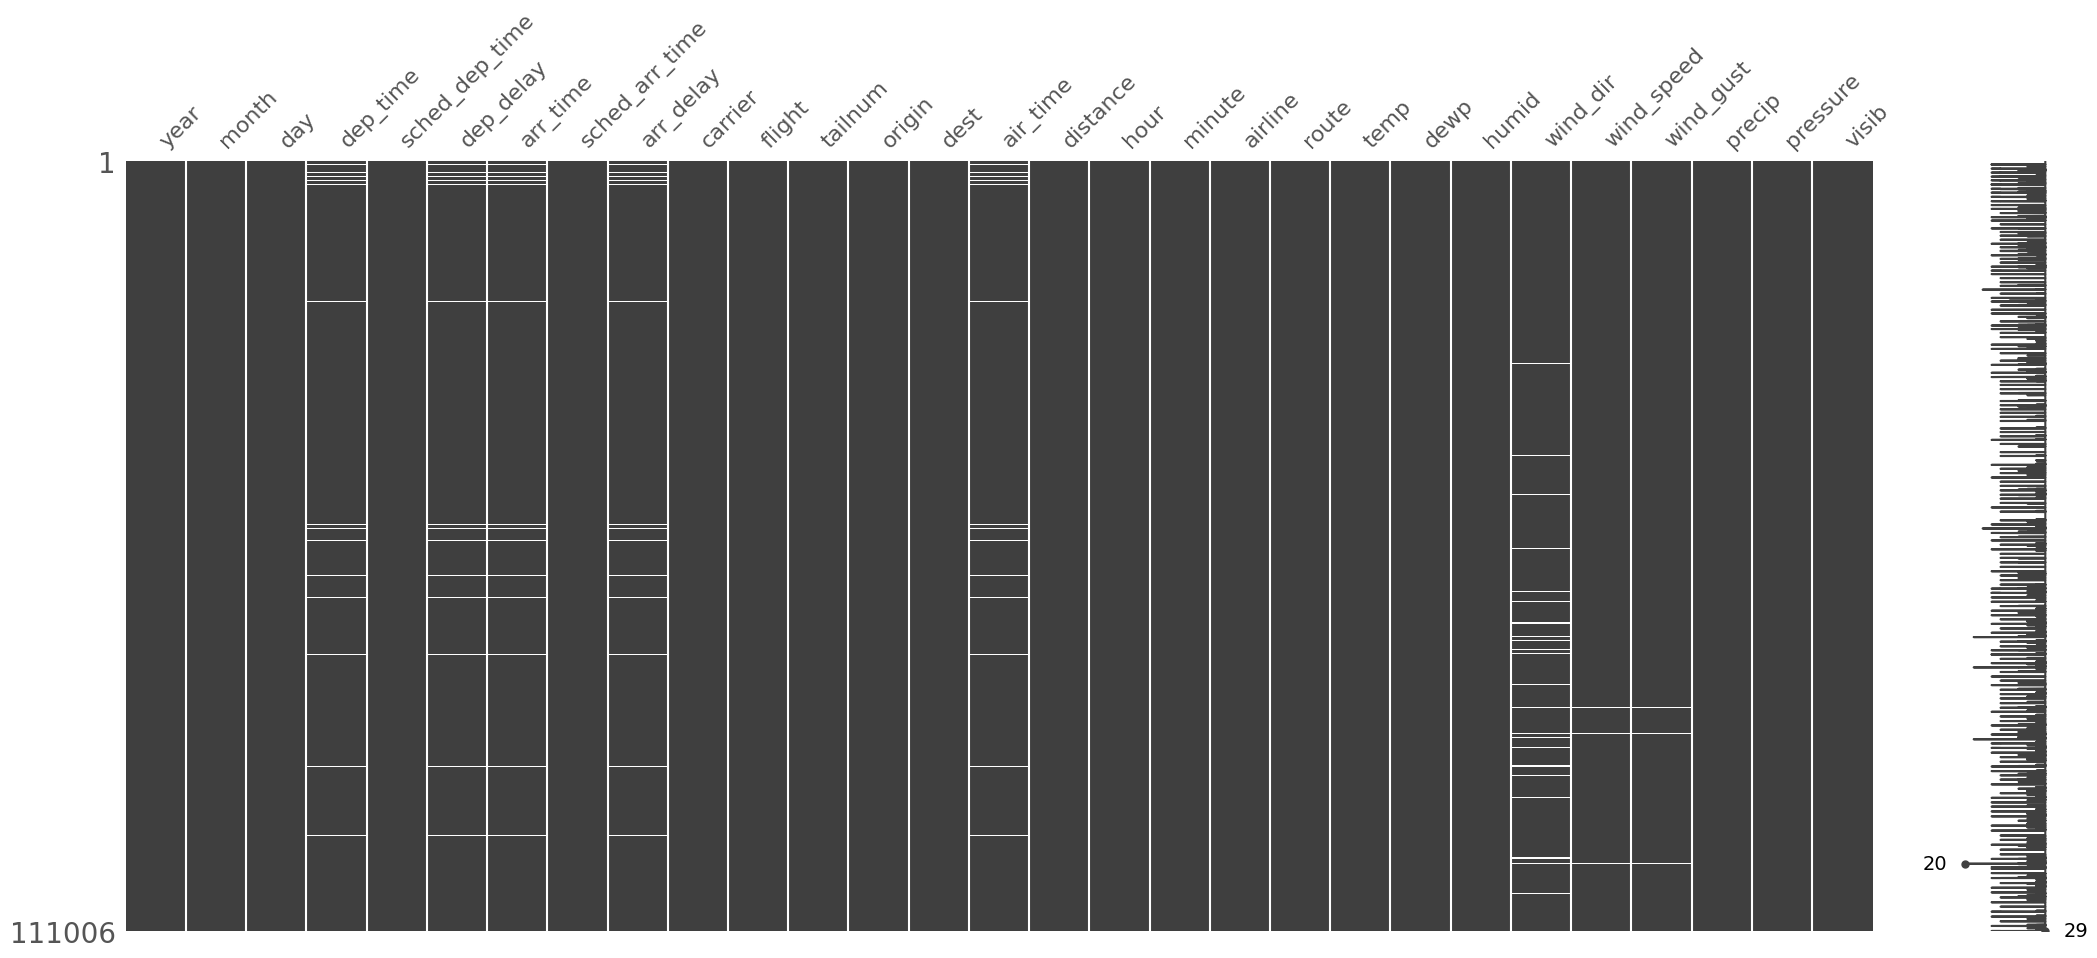

In [53]:
plt.figure(figsize=(6, 4)) 
msno.matrix(df)
plt.show()

In [54]:
df[["dep_time","dep_delay","arr_time","arr_delay","air_time"]].isnull().all(axis=1).sum()

2440

In [55]:
threshold = len(df) * 0.05
threshold

5550.3


**Distribution of delays according to airline**


- The majority of flight cancellations belong to **Alaska Airlines**, accounting for **more than 50%** of all canceled flights.  
The **lowest number of cancellations** was recorded by **Hawaiian Airlines**.

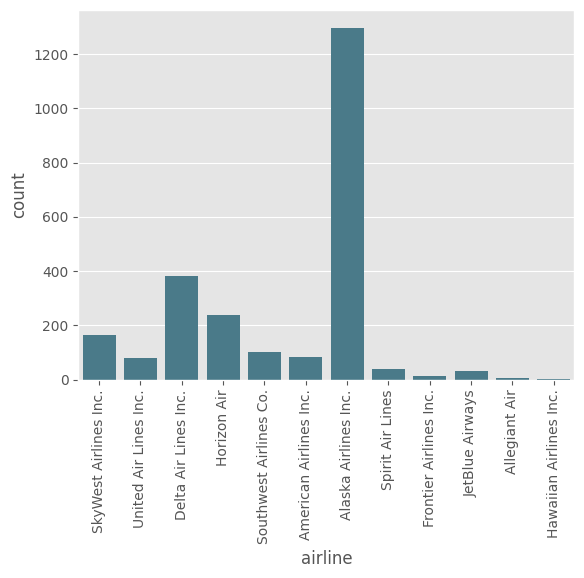

In [56]:
missing_df=df.loc[df[["dep_time","dep_delay","arr_time","arr_delay","air_time"]].isnull().all(axis=1),"airline"].reset_index()
sns.countplot(data=missing_df,x="airline")
plt.xticks(rotation=90)
plt.show()

In [57]:
df.dropna(subset=["dep_time", "dep_delay", "arr_time", "arr_delay", "air_time"], how="all", inplace=True)
df.dropna(subset=["arr_time", "arr_delay", "air_time"], inplace=True)
df.isnull().sum()

year                 0
month                0
day                  0
dep_time             0
sched_dep_time       0
dep_delay            0
arr_time             0
sched_arr_time       0
arr_delay            0
carrier              0
flight               0
tailnum              0
origin               0
dest                 0
air_time             0
distance             0
hour                 0
minute               0
airline              0
route                0
temp                 0
dewp                 0
humid                0
wind_dir          3113
wind_speed         273
wind_gust          273
precip               0
pressure             0
visib                0
dtype: int64

## Data Cleaning Steps for Time Variables

- `dep_time` and `arr_time` are floats, while `sched_dep_time` and `sched_arr_time` are integers.  
  Used `.zfill(4)` to convert all to zero-padded strings of length 4, with an extra integer cast for float columns.

- Combined `dep_time`, `arr_time`, `sched_dep_time`, and `sched_arr_time` with a `date_string` (YYYYMMDD) to form consistent datetime objects.

- `sched_dep_time` and `sched_arr_time` converted correctly without issue.  
  However, some `dep_time` and `arr_time` values were incorrectly recorded as `"2400"` instead of `"0000"`.

- Replaced `"2400"` with `"0000"` to fix format errors.

- **Important:** When changing `"2400"` to `"0000"`, the date should be incremented by one day to keep the datetime accurate.

- Applied this logic to adjust the day when the hour is 0 after conversion.

- Result: Reliable and consistent datetime columns.

In [58]:
df["date"] = pd.to_datetime(df[["year","month","day"]])
df["date_string"] = df["date"].astype(str).str.replace("-","")

df["dep_time"] = df["dep_time"].astype(int).astype(str).str.zfill(4)
df["sched_dep_time"] = df["sched_dep_time"].astype(str).str.zfill(4)
df["arr_time"] = df["arr_time"].astype(int).astype(str).str.zfill(4)
df["sched_arr_time"] = df["sched_arr_time"].astype(str).str.zfill(4)

df["sched_dep_time"] = df["date_string"].str.cat(df["sched_dep_time"])
df["sched_dep_time"] = pd.to_datetime(df["sched_dep_time"],format="%Y%m%d%H%M")

df["sched_arr_time"] = df["date_string"].str.cat(df["sched_arr_time"])
df["sched_arr_time"] = pd.to_datetime(df["sched_arr_time"],format="%Y%m%d%H%M")

df["dep_time"] = df["dep_time"].replace({"2400":"0000"})
df["dep_time"] = df["date_string"].str.cat(df["dep_time"])
df["dep_time"] = pd.to_datetime(df["dep_time"],format="%Y%m%d%H%M")

df.loc[df["dep_time"].dt.hour == 0, "dep_time"] += pd.Timedelta(days=1)

df["arr_time"] = df["arr_time"].replace({"2400":"0000"})
df["arr_time"] = df["date_string"].str.cat(df["arr_time"])
df["arr_time"] = pd.to_datetime(df["arr_time"],format="%Y%m%d%H%M")
df.loc[df["arr_time"].dt.hour == 0, "arr_time"] += pd.Timedelta(days=1)

df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,airline,route,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,date,date_string
0,2022,1,1,2022-01-02 00:01:00,2022-01-01 23:59:00,2.0,2022-01-01 06:04:00,2022-01-01 06:18:00,-14.0,UA,555,N405UA,SEA,IAH,221.0,1874,23,59,United Air Lines Inc.,SEA-IAH,33.0,23.0,66.06,160.0,8.05546,9.270062,0.0,1022.9,10.0,2022-01-01,20220101
1,2022,1,1,2022-01-02 00:01:00,2022-01-01 22:50:00,71.0,2022-01-01 02:42:00,2022-01-01 01:42:00,60.0,AS,72,N265AK,SEA,FAI,193.0,1533,22,50,Alaska Airlines Inc.,SEA-FAI,32.0,23.0,69.04,170.0,9.20624,10.594357,0.0,1023.4,10.0,2022-01-01,20220101
2,2022,1,1,2022-01-02 00:10:00,2022-01-01 23:55:00,15.0,2022-01-01 07:59:00,2022-01-01 07:30:00,29.0,AS,270,N274AK,SEA,ATL,261.0,2182,23,55,Alaska Airlines Inc.,SEA-ATL,33.0,23.0,66.06,160.0,8.05546,9.270062,0.0,1022.9,10.0,2022-01-01,20220101
3,2022,1,1,2022-01-02 00:25:00,2022-01-01 23:50:00,35.0,2022-01-01 06:06:00,2022-01-01 05:50:00,16.0,AS,7,N281AK,SEA,ORD,193.0,1721,23,50,Alaska Airlines Inc.,SEA-ORD,33.0,23.0,66.06,160.0,8.05546,9.270062,0.0,1022.9,10.0,2022-01-01,20220101
4,2022,1,1,2022-01-02 00:35:00,2022-01-01 23:49:00,46.0,2022-01-01 06:16:00,2022-01-01 05:45:00,31.0,UA,507,N426UA,PDX,ORD,196.0,1739,23,49,United Air Lines Inc.,PDX-ORD,33.0,19.0,55.75,120.0,6.90468,7.945768,0.0,1025.1,10.0,2022-01-01,20220101


In [59]:
df.select_dtypes(include=["datetime64"]).columns

Index(['dep_time', 'sched_dep_time', 'arr_time', 'sched_arr_time', 'date'], dtype='object')

**Filling Missing Values**  

- The variable `wind_dir`, which represents wind direction, accounts for **2.87%** of the dataset. Since the missing values are limited to a single variable and it represents a weather-related feature, dropping these rows would result in unnecessary data loss. Therefore, it was considered more beneficial to fill these missing values.  
- The same method was applied to the `wind_speed` and `wind_gust` variables, which represent wind speed and wind gust, respectively.


In [60]:
wind_dir=df["wind_dir"].isnull().sum()
ratio_wind = wind_dir/len(df) * 100
print(f"The missing ratio of the 'wind_dir' variable in the entire dataset is %{ratio_wind:.2f}.")

The missing ratio of the 'wind_dir' variable in the entire dataset is %2.87.


**Handling Missing `wind_dir`, `wind_speed`, and `wind_gust` Values with Forward Fill & Removing July Spillover**

- The dataset was sorted based on the departure time (`dep_time`), which includes year, month, day, hour, and minute.
  This sorting ensures that forward fill (`ffill`) fills missing values using the most recent valid observation, even at minute-level granularity.

- After sorting, the last 10 rows were inspected and found to have spilled over into July. This was due to a previous operation where one day was added to handle cases like "2400" being converted to "0000".

- Since only 10 records were affected and they belonged to the next month, they were removed from the dataset to maintain consistency.

In [61]:
df = df.sort_values("dep_time").reset_index(drop=True)
df.tail(12)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,airline,route,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,date,date_string
108320,2022,6,30,2022-06-30 23:53:00,2022-06-30 23:56:00,-3.0,2022-06-30 07:22:00,2022-06-30 07:31:00,-9.0,DL,841,N838DN,PDX,ATL,253.0,2172,23,56,Delta Air Lines Inc.,PDX-ATL,81.0,54.0,39.37,330.0,8.05546,9.270062,0.0,1016.4,10.0,2022-06-30,20220630
108321,2022,6,30,2022-06-30 23:59:00,2022-06-30 23:59:00,0.0,2022-06-30 05:52:00,2022-06-30 06:08:00,-16.0,UA,603,N31412,PDX,IAH,217.0,1825,23,59,United Air Lines Inc.,PDX-IAH,81.0,54.0,39.37,330.0,8.05546,9.270062,0.0,1016.4,10.0,2022-06-30,20220630
108322,2022,6,30,2022-07-01 00:00:00,2022-06-30 23:58:00,2.0,2022-06-30 07:47:00,2022-06-30 07:58:00,-11.0,AA,830,N916US,SEA,CLT,256.0,2279,23,58,American Airlines Inc.,SEA-CLT,75.0,47.0,36.87,10.0,10.35702,11.918651,0.0,1019.4,10.0,2022-06-30,20220630
108323,2022,6,30,2022-07-01 00:01:00,2022-06-30 21:35:00,146.0,2022-06-30 01:42:00,2022-06-30 23:20:00,142.0,WN,792,N480WN,PDX,OAK,83.0,543,21,35,Southwest Airlines Co.,PDX-OAK,76.0,54.0,46.57,270.0,8.05546,9.270062,0.0,1017.6,10.0,2022-06-30,20220630
108324,2022,6,30,2022-07-01 00:01:00,2022-06-30 23:32:00,29.0,2022-06-30 05:45:00,2022-06-30 05:21:00,24.0,AA,348,N940NN,PDX,ORD,193.0,1739,23,32,American Airlines Inc.,PDX-ORD,81.0,54.0,39.37,330.0,8.05546,9.270062,0.0,1016.4,10.0,2022-06-30,20220630
108325,2022,6,30,2022-07-01 00:10:00,2022-06-30 00:15:00,-5.0,2022-06-30 05:14:00,2022-06-30 05:33:00,-19.0,DL,282,N341DN,PDX,MSP,161.0,1426,0,15,Delta Air Lines Inc.,PDX-MSP,74.0,55.0,51.64,320.0,10.35702,11.918651,0.0,1019.2,10.0,2022-06-30,20220630
108326,2022,6,30,2022-07-01 00:13:00,2022-06-30 00:05:00,8.0,2022-06-30 05:44:00,2022-06-30 06:02:00,-18.0,UA,501,N73259,PDX,ORD,189.0,1739,0,5,United Air Lines Inc.,PDX-ORD,74.0,55.0,51.64,320.0,10.35702,11.918651,0.0,1019.2,10.0,2022-06-30,20220630
108327,2022,6,30,2022-07-01 00:17:00,2022-06-30 23:59:00,18.0,2022-06-30 05:48:00,2022-06-30 05:57:00,-9.0,UA,782,N39461,SEA,ORD,192.0,1721,23,59,United Air Lines Inc.,SEA-ORD,75.0,47.0,36.87,10.0,10.35702,11.918651,0.0,1019.4,10.0,2022-06-30,20220630
108328,2022,6,30,2022-07-01 00:24:00,2022-06-30 00:30:00,-6.0,2022-06-30 03:03:00,2022-06-30 03:00:00,3.0,AS,88,N615AS,SEA,ANC,190.0,1448,0,30,Alaska Airlines Inc.,SEA-ANC,68.0,50.0,52.51,NaN,6.90468,7.945768,0.0,1021.9,10.0,2022-06-30,20220630
108329,2022,6,30,2022-07-01 00:25:00,2022-06-30 00:30:00,-5.0,2022-06-30 06:02:00,2022-06-30 06:27:00,-25.0,UA,505,N27213,PDX,ORD,199.0,1739,0,30,United Air Lines Inc.,PDX-ORD,74.0,55.0,51.64,320.0,10.35702,11.918651,0.0,1019.2,10.0,2022-06-30,20220630


In [62]:
df = df.iloc[:-10]

In [63]:
df.tail(1)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,airline,route,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,date,date_string
108321,2022,6,30,2022-06-30 23:59:00,2022-06-30 23:59:00,0.0,2022-06-30 05:52:00,2022-06-30 06:08:00,-16.0,UA,603,N31412,PDX,IAH,217.0,1825,23,59,United Air Lines Inc.,PDX-IAH,81.0,54.0,39.37,330.0,8.05546,9.270062,0.0,1016.4,10.0,2022-06-30,20220630


In [64]:
# ffill
wind_data_to_be_filled = ["wind_dir","wind_speed","wind_gust"]
for value in wind_data_to_be_filled:
    df[value].ffill(inplace=True)

In [65]:
df[["wind_dir"]].describe().T

,count,mean,std,min,25%,50%,75%,max
wind_dir,108322.0,165.347575,101.61994,0.0,100.0,180.0,220.0,360.0


In [66]:
df[["wind_speed"]].describe().T

,count,mean,std,min,25%,50%,75%,max
wind_speed,108322.0,6.973925,4.494517,0.0,4.60312,6.90468,9.20624,27.61872


In [67]:
df[["wind_gust"]].describe().T

,count,mean,std,min,25%,50%,75%,max
wind_gust,108322.0,8.025454,5.1722,0.0,5.297178,7.945768,10.594357,31.783071


**Checking `dep_delay` and `arr_delay`  Variables**

- After converting the date columns into the proper datetime format, the variables `dep_delay`, `arr_delay`, and `air_time` in the dataset were validated for correctness.


In [68]:
df.shape

(108322, 31)

In [69]:
dep_delay_check = df['dep_delay'] == ((df['dep_time'] - df['sched_dep_time']).dt.total_seconds() / 60)
diff_dep_delay = len(df) - dep_delay_check.sum()
print("Diff rows:", diff_dep_delay)

Diff rows: 824


- The inconsistent records may have resulted from incorrect date entries. Since the `dep_delay` column contains more reliable and realistic values, it was considered the correct reference, and the conflicting records were removed from the dataset.


In [70]:
df = df[dep_delay_check]
diff_dep_delay = len(df) - dep_delay_check.sum()
print("Number of rows with differing values:", diff_dep_delay)

Number of rows with differing values: 0


- arr_delay

In [71]:
arr_delay_check = df['arr_delay'] == ((df['arr_time'] - df['sched_arr_time']).dt.total_seconds() / 60)
diff_arr_delay = len(df) - arr_delay_check.sum()
print("Number of rows with differing values:", diff_arr_delay)

Number of rows with differing values: 1884


In [72]:
df = df[arr_delay_check]
diff_arr_delay = len(df) - arr_delay_check.sum()
print("Number of rows with differing values:", diff_arr_delay)

Number of rows with differing values: 0


- **As a result of all validation and deletion steps, the data removed remained below the commonly accepted 5% threshold in the industry. Moreover, considering the size of the dataset, these removed values are not of critical importance.**

- **If these values had belonged to a minority class in a dataset with class imbalance and were important for the target variable, then instead of removing them, alternative techniques could have been applied.**

- **After the cleaning process, a consistent and clean dataset has been obtained.**


In [73]:
row_data = 111006
deleted_data = row_data - df.shape[0]
total_cleaned_data_percentage = (deleted_data / row_data ) * 100
print(f"Total dropped data %'{total_cleaned_data_percentage:.2f}.")

Total dropped data %'4.86.


In [74]:
df.isnull().sum()

year              0
month             0
day               0
dep_time          0
sched_dep_time    0
dep_delay         0
arr_time          0
sched_arr_time    0
arr_delay         0
carrier           0
flight            0
tailnum           0
origin            0
dest              0
air_time          0
distance          0
hour              0
minute            0
airline           0
route             0
temp              0
dewp              0
humid             0
wind_dir          0
wind_speed        0
wind_gust         0
precip            0
pressure          0
visib             0
date              0
date_string       0
dtype: int64

**Check Duplicates**

In [75]:
df[df.duplicated(keep=False)]

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,airline,route,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,date,date_string


In [76]:
df.head(3)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,airline,route,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,date,date_string
0,2022,1,1,2022-01-01 01:04:00,2022-01-01 00:43:00,21.0,2022-01-01 09:36:00,2022-01-01 09:30:00,6.0,AA,501,N413AN,SEA,MIA,312.0,2724,0,43,American Airlines Inc.,SEA-MIA,25.0,14.0,62.50,350.0,8.05546,9.270062,0.0,1020.7,10.0,2022-01-01,20220101
4,2022,1,1,2022-01-01 05:13:00,2022-01-01 05:05:00,8.0,2022-01-01 08:52:00,2022-01-01 08:46:00,6.0,UA,850,N24202,SEA,DEN,133.0,1024,5,5,United Air Lines Inc.,SEA-DEN,24.1,17.1,74.27,110.0,6.90468,7.945768,0.0,1023.0,10.0,2022-01-01,20220101
5,2022,1,1,2022-01-01 05:14:00,2022-01-01 05:15:00,-1.0,2022-01-01 08:31:00,2022-01-01 08:45:00,-14.0,WN,558,N7738A,PDX,PHX,121.0,1009,5,15,Southwest Airlines Co.,PDX-PHX,28.0,15.1,57.93,130.0,9.20624,10.594357,0.0,1023.1,10.0,2022-01-01,20220101


# Explatory Data Analysis / Feature Engineering

In [77]:
 
def single_variable_multiple_plot(data,type="float64",numeric=True):
    """
    Generates multiple plots for a single variable in the dataset to explore its distribution.

    For numerical variables:
    - Histogram
    - Boxplot
    - Kernel Density Estimate (KDE) plot

    For categorical variables:
    - Countplot (bar chart of value counts)
    - Pie chart

    Parameters
    ----------
    data : DataFrame
        The dataset containing the variable to be visualized.
    type : str, default="float64"
        The data type of the variable to be plotted. For example, "float64" or "object".
    numeric : bool, default=True
        Whether the variable is numerical (True) or categorical (False).

    Returns
    -------
    None
    """
 
    if numeric: 
         numeric_columns= [col for col in data.columns if data[col].dtype == type]
         for i in numeric_columns:
            fig, axes = plt.subplots(nrows=1,ncols=3, figsize=(20,4))
            sns.histplot(x=data[i],bins=10,ax=axes[0])
            axes[0].set_title(i)
            sns.boxplot(x=data[i],ax=axes[1])
            axes[1].set_title(i)
            sns.kdeplot(x=data[i],ax=axes[2])
            axes[2].set_title(i)
            plt.show()
    
    else:
         categoric_columns= [col for col in data.columns if data[col].dtype in ["object","category","int32"]]
         for i in categoric_columns:
            fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(16,8))
            sns.countplot(data=data, x=i,order=data[i].value_counts().index, ax=axes[0])
            axes[0].set_title(i)
            axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
            plt.pie(data[i].value_counts(), autopct='%1.1f%%',labels=data[i].value_counts().index)
            axes[1].set_title(i)
            axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
            plt.tight_layout()
            plt.show()

In [78]:
def custom_barplot(data, categoric_value, numeric_value, agg_func):
    """
    Groups the dataset by a categorical variable and calculates a statistical summary 
    of a numerical variable for each group, then plots these summaries as a barplot.

    Parameters:
    -----------
    data : pandas.DataFrame
        The dataset containing the variables.
    categoric_value : str
        The name of the categorical column to group by.
    numeric_value : str
        The name of the numerical column for which the statistical summary is computed.
    agg_func : str or callable
        The aggregation function to apply on each group, e.g. 'mean', 'median', 'sum', or a custom function like numpy.mean.

    Returns:
    --------
    pandas.DataFrame
        A DataFrame containing the grouped and aggregated data, sorted descending by the numeric summary.
    """
    sorted_df = data.groupby(categoric_value)[numeric_value].agg(agg_func).reset_index().sort_values(numeric_value, ascending=False)
    sns.barplot(x=categoric_value, y=numeric_value, data=data, estimator=agg_func, order=sorted_df[categoric_value], ci=False)
    plt.xticks(rotation=90)
    plt.show()
    return sorted_df


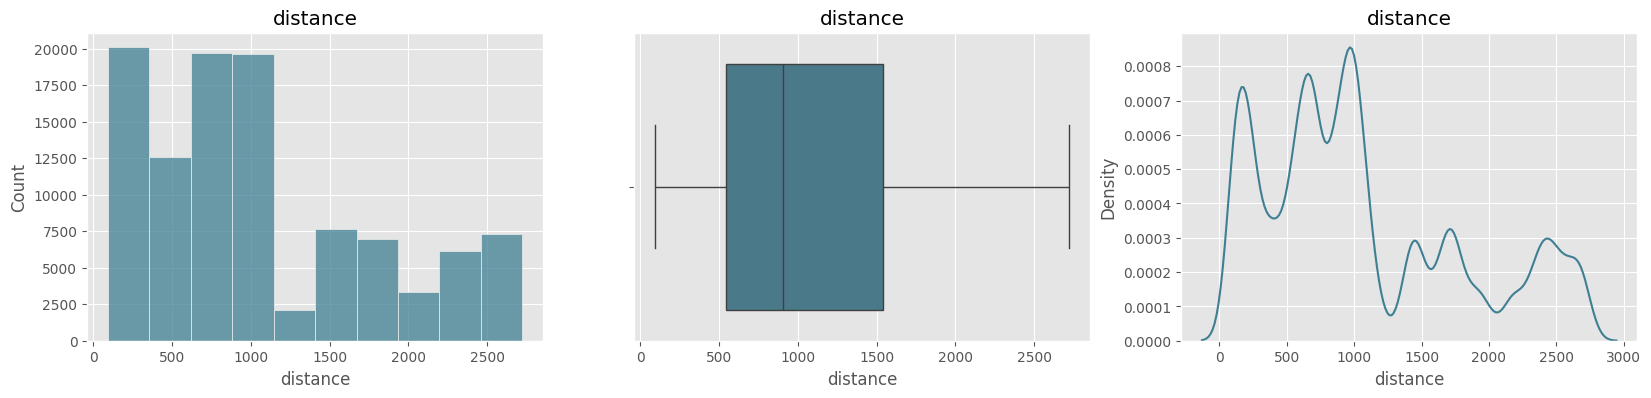

In [79]:
single_variable_multiple_plot(df[["distance"]],type="int64",numeric=True)

## Total Flight Distances by Airlines

- When examining the total flight distances covered by different airlines, **Alaska Airlines Inc.** has flown the longest distance, while **Allegiant Air** has flown the shortest distance.  
- The ranking and the corresponding plot are shown below.

In [80]:
df.groupby("airline")["distance"].sum().reset_index().sort_values("distance",ascending=False)

,airline,distance
0,Alaska Airlines Inc.,51901234
3,Delta Air Lines Inc.,22395311
11,United Air Lines Inc.,8248029
8,SkyWest Airlines Inc.,7107696
6,Horizon Air,6788743
2,American Airlines Inc.,5814178
9,Southwest Airlines Co.,5747645
5,Hawaiian Airlines Inc.,1884424
7,JetBlue Airways,1386325
10,Spirit Air Lines,662752


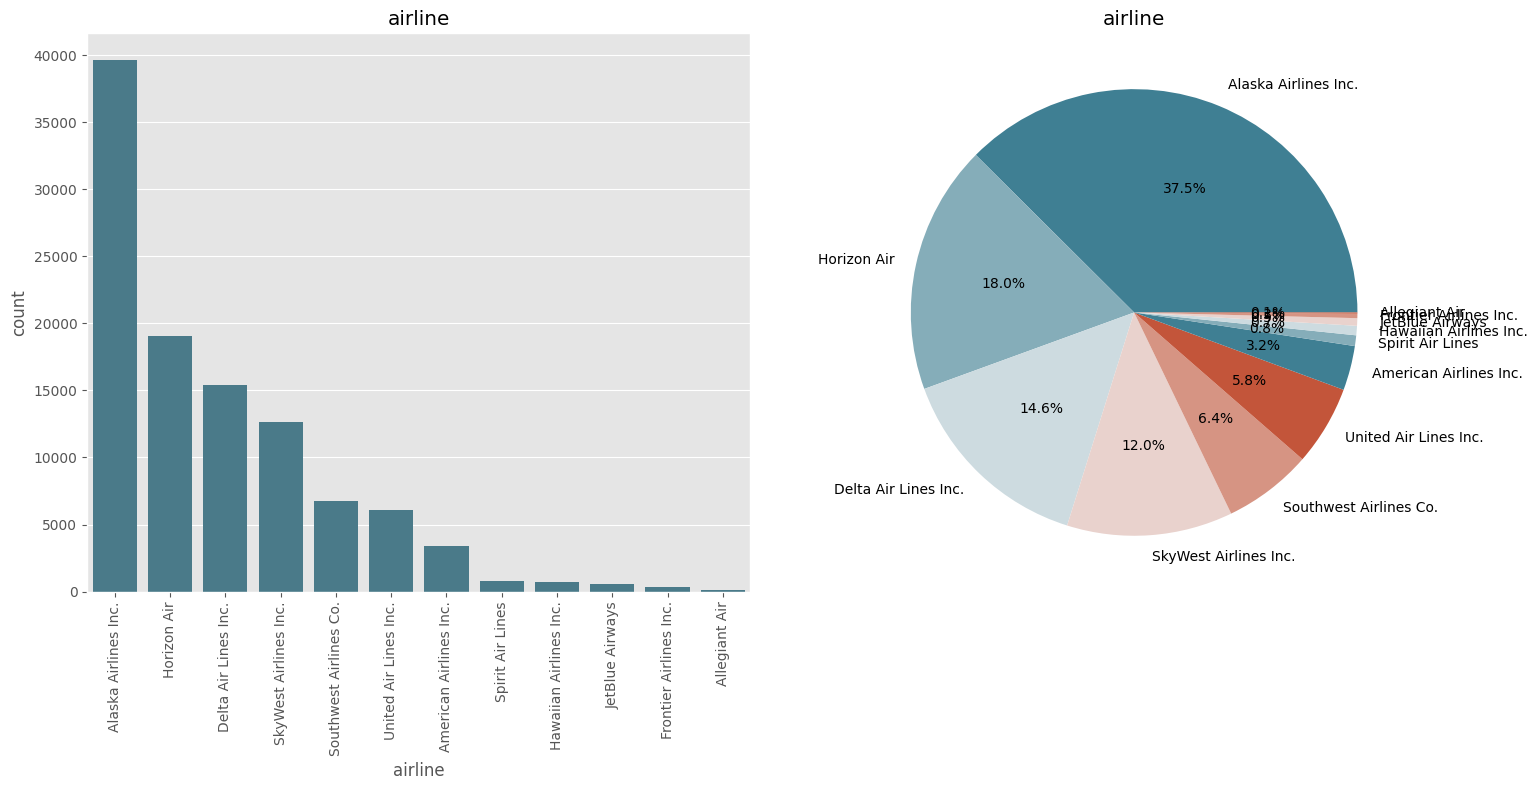

In [81]:
single_variable_multiple_plot(df[["airline"]],type="object",numeric=False)

In [82]:
df["distance_ratio_by_total"] = df.groupby("airline")["distance"].transform("sum") / df["distance"].sum()

## Grouping Distances

In [83]:
df[["distance"]].describe().T

,count,mean,std,min,25%,50%,75%,max
distance,105614.0,1063.636402,746.772089,93.0,543.0,909.0,1542.0,2724.0


In [84]:
bins = [0, 500, 1000, np.inf]
labels = ["0-500 miles", "500-1000 miles", "1000+ miles"]
df["distance_category"] = pd.cut(df["distance"],bins=bins, labels=labels, ordered=True)
df[["distance_category"]].value_counts()

distance_category
1000+ miles          42737
500-1000 miles       37836
0-500 miles          25041
Name: count, dtype: int64

## Comparing Airline Performance Based on Delays

**Distribution of Departure and Arrival Delay Times**

- When examining the mean, median, minimum, and maximum values, the median values are smaller than the means, indicating that the distributions are highly right-skewed.  
- Most values generally fall within the range of 0 to 200 minutes.


In [85]:
df[["dep_delay","arr_delay"]].describe().T

,count,mean,std,min,25%,50%,75%,max
dep_delay,105614.0,6.833924,29.388242,-36.0,-5.0,-2.0,6.0,939.0
arr_delay,105614.0,1.176501,31.420228,-65.0,-14.0,-5.0,6.0,907.0


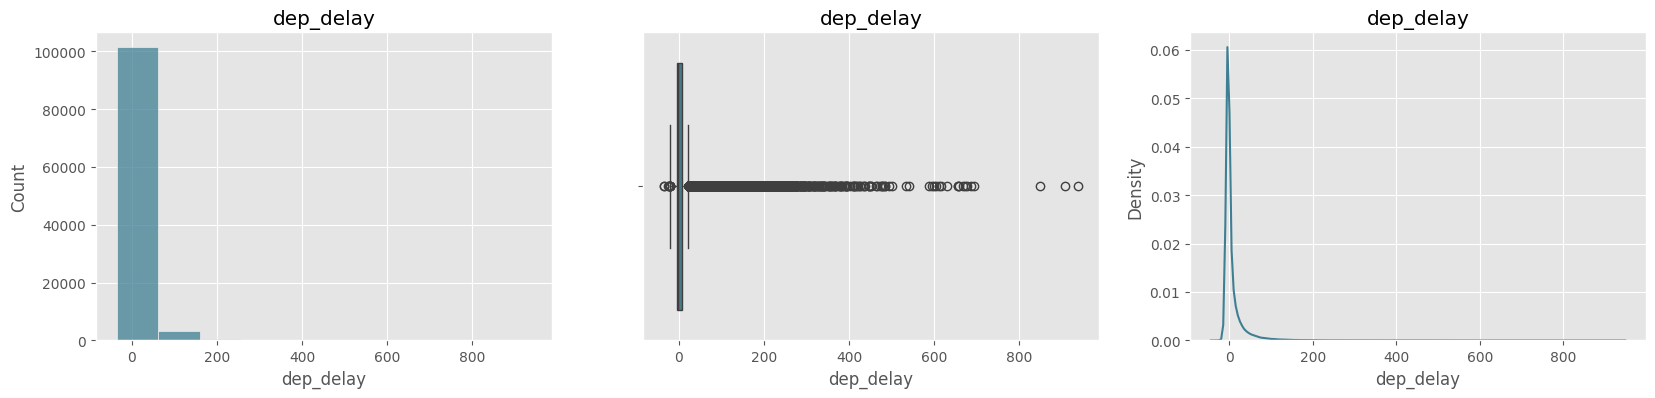

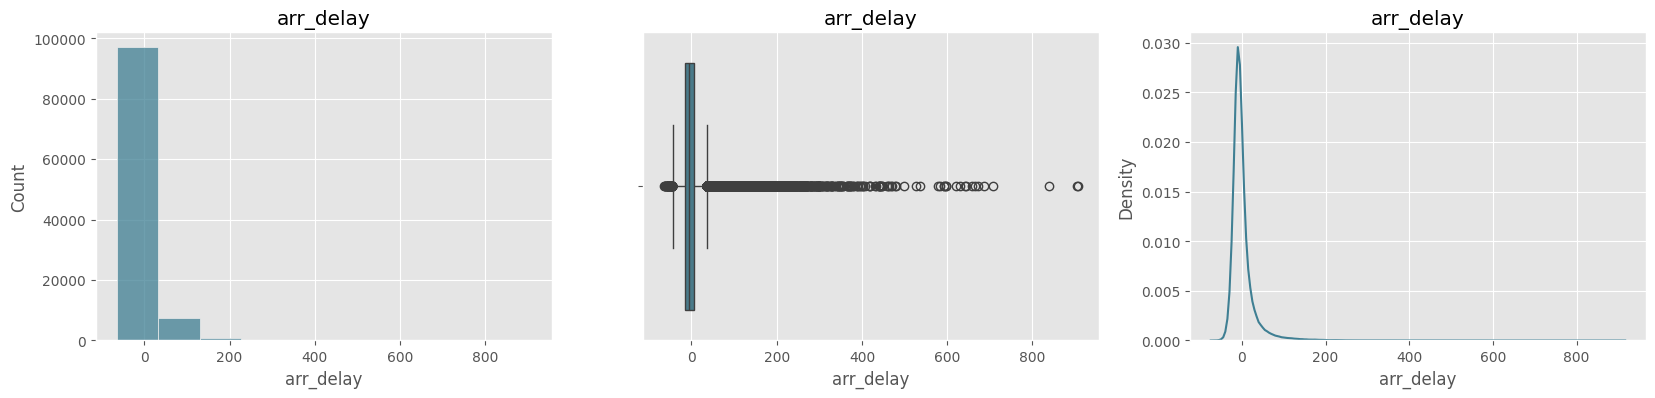

In [86]:
single_variable_multiple_plot(df[["dep_delay","arr_delay"]],numeric=True)


- Below is the bar chart showing airlines with the highest total departure delays (`dep_delay`).  
- Allegiant Air appears to have the lowest total departure delay. However, it is more meaningful to evaluate delays relative to the number of flights.  
- Since Alaska Airlines has the highest number of flights, it is natural that their total delay is also the highest.

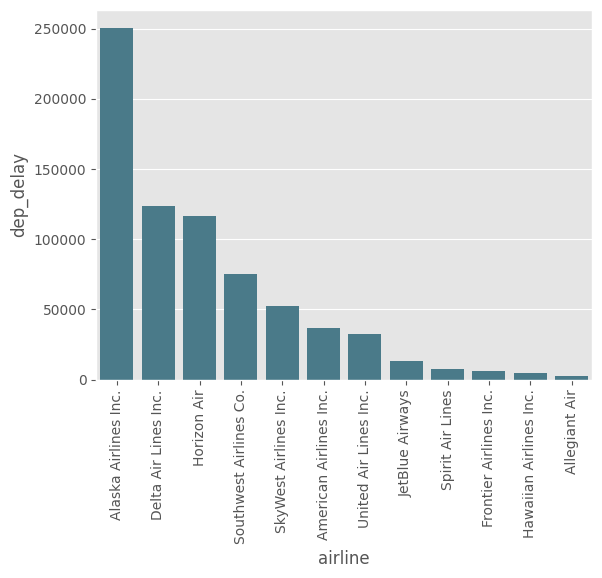

In [87]:
_ = custom_barplot(df, "airline","dep_delay",sum)

- Below is the bar chart showing airlines with the highest total arrival delays (`arr_delay`).  
- United Air Lines appears to have the lowest total arrival delay. However, it is more meaningful to evaluate delays relative to the number of flights.  
- Since Alaska Airlines has the highest number of flights, it is natural that their total delay is also the highest.

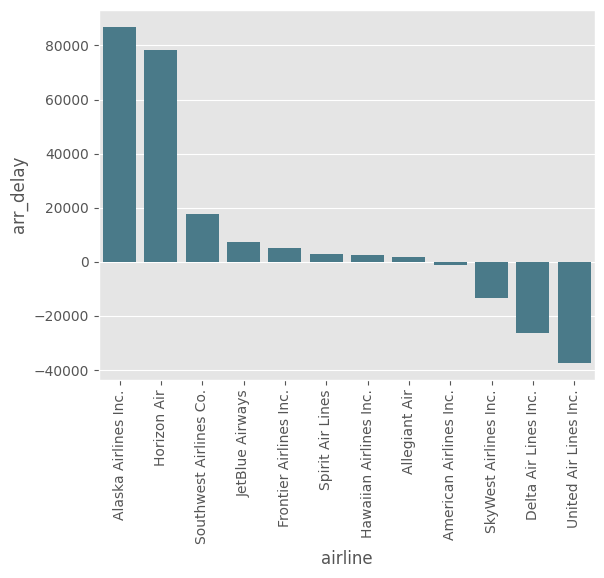

In [88]:
_ = custom_barplot(df, "airline","arr_delay",sum)

**The performance evaluation of airlines depends on many factors, including customer satisfaction surveys, customer reviews, budget, aircraft quality, and more. Due to limited time to collect and analyze all this information, a simple performance KPI was calculated by dividing the total daily departure and arrival delays by the total daily number of flights.**

**In this simple approach, a lower KPI value indicates better performance. To create this KPI, the daily number of flights for each airline was first calculated.**


- Daily total number of flights for each airline

In [89]:
df.groupby(["airline","date"]).size().reset_index().head()

,airline,date,0
0,Alaska Airlines Inc.,2022-01-01,169
1,Alaska Airlines Inc.,2022-01-02,182
2,Alaska Airlines Inc.,2022-01-03,160
3,Alaska Airlines Inc.,2022-01-04,183
4,Alaska Airlines Inc.,2022-01-05,175


- Adding the daily total number of flights for each airline

In [90]:
df["daily_flight_count"] = df.groupby(["airline","date"]).transform("size")

- Validation

In [91]:
df.groupby(["airline","date"])["daily_flight_count"].mean().reset_index().head()

,airline,date,daily_flight_count
0,Alaska Airlines Inc.,2022-01-01,169.0
1,Alaska Airlines Inc.,2022-01-02,182.0
2,Alaska Airlines Inc.,2022-01-03,160.0
3,Alaska Airlines Inc.,2022-01-04,183.0
4,Alaska Airlines Inc.,2022-01-05,175.0


**Distribution of the Newly Created `daily_flight_count` Variable**

- When examining the mean, median, minimum, and maximum values, the mean and median are closer to each other compared to other variables, indicating a distribution closer to normal.  
- The values are roughly concentrated between 0–125 and 175–250.

In [92]:
df[["daily_flight_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
daily_flight_count,105614.0,128.5187,76.947226,1.0,73.0,101.0,213.0,252.0


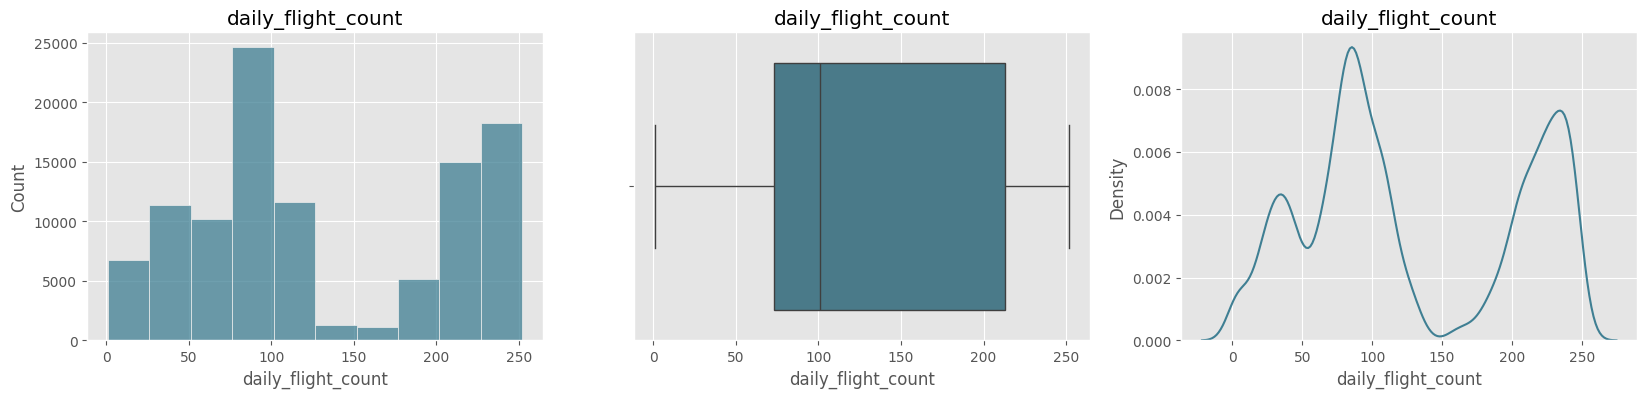

In [93]:
single_variable_multiple_plot(df[["daily_flight_count"]],type="int64",numeric=True)

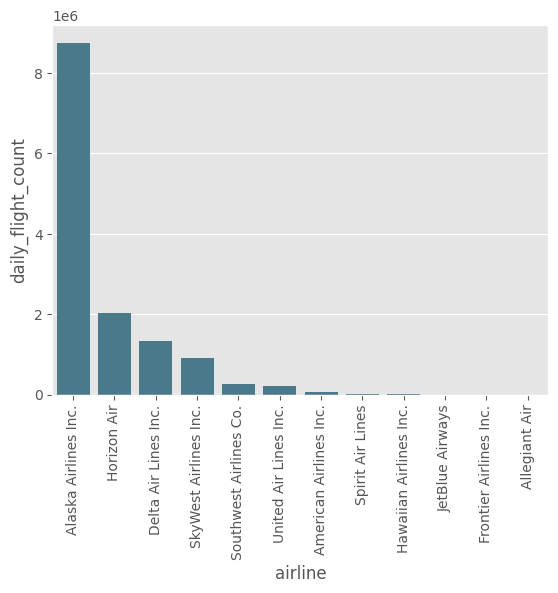

In [94]:
_ = custom_barplot(df, "airline","daily_flight_count",sum)

## Is there a specific hour of the day and/or week of the year when the rotation time is higher?

Upon examining the hours in the dataset, it was determined that the `hour` variable is derived from `sched_dep_time`. Therefore, the analysis was conducted using the `hour` variable. Additionally, to identify the hours with the most delays, it makes sense to use the scheduled departure hour as the reference.



**dep_time Hour Check**

- The difference observed based on the `hour` variable in the main dataset is due to the fact that the `hour` variable was derived from the scheduled departure time (`sched_dep_time`).


In [106]:
df["hour_check_dep"] = df["dep_time"].dt.hour

In [107]:
hour_check_dep = df['hour'] == df['hour_check_dep']
diff_hour_dep = len(df) - hour_check_dep.sum()
print("Number of rows with differing values:", diff_hour_dep)

Number of rows with differing values: 23442


**sched_dep_time Hour Check**

- Here, we see that the `hour` variable in the dataset is derived from the `sched_dep_time` column.  
- Upon examining the data, hours 2, 3, and 4 are missing.  
- Since the dataset contains flights from two airports (SEA, PDX), the absence of delays during hours 2, 3, and 4 may indicate that no flights were scheduled at these hours at these airports.


In [108]:
df[["origin"]].value_counts()

origin
SEA       78169
PDX       27445
Name: count, dtype: int64

In [109]:
df["hour_check_sched"] = df["sched_dep_time"].dt.hour

In [110]:
hour_check_sched = df['hour'] == df['hour_check_sched']
diff_hour_sched = len(df) - hour_check_sched.sum()
print("Number of rows with differing values:", diff_hour_sched)

Number of rows with differing values: 0


In [111]:
df.groupby("hour")["dep_delay"].sum().reset_index().head(6)

,hour,dep_delay
0,0,9998.0
1,1,73.0
2,5,6897.0
3,6,13403.0
4,7,34329.0
5,8,37002.0


**Hourly Flight Counts**

- When grouped by hour and examining the number of flights, it is confirmed that there are no flights during hours 2, 3, and 4.


In [112]:
hourly_flight_count = df.groupby("hour").size().reset_index()
hourly_flight_count= hourly_flight_count.rename(columns={0:"hourly_flight_count"})
hourly_flight_count.head()

,hour,hourly_flight_count
0,0,155
1,1,18
2,5,2854
3,6,5749
4,7,8827


**Hourly Flight Counts Plot**

- Examining this plot, we see that the highest number of flights occur at 07:00 and 11:00, while the fewest flights take place at 00:00, 01:00, and 05:00.


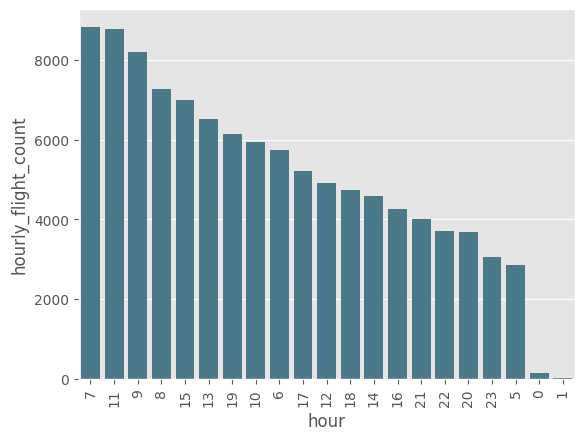

In [113]:
_ = custom_barplot(hourly_flight_count,"hour","hourly_flight_count",sum)

**Haurly Delays**

In [114]:
total_hourly_delays = df.groupby("hour")["dep_delay"].sum().reset_index()
total_hourly_delays

,hour,dep_delay
0,0,9998.0
1,1,73.0
2,5,6897.0
3,6,13403.0
4,7,34329.0
5,8,37002.0
6,9,46508.0
7,10,40886.0
8,11,71373.0
9,12,37704.0


**Hourly Delay Plot**

- The highest delays occur at 11:00, which is a peak flight hour. However, despite 07:00 being the busiest hour in terms of flights, the delay amount is lower. This may indicate that airports take extra precautions to avoid delays at 07:00 due to various factors. Further detailed analysis could explain why this hour is important.  
- The hours with the least delays, which also coincide with the shortest flight durations, are 00:00, 01:00, and 05:00.  
- There is a special case at 00:00 where, despite a very low number of flights, delays are very high. This could be due to the timing coinciding with the exact change of the day.


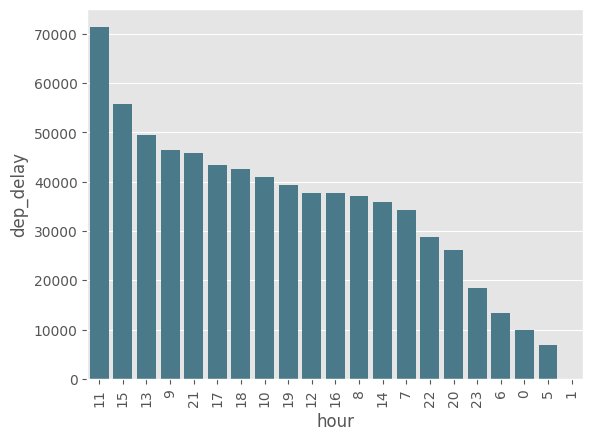

In [115]:
_ = custom_barplot(total_hourly_delays,"hour","dep_delay",sum)

## Identification of Routes with the Highest Delay (ROTAR) Durations

**There are 149 routes in the dataset.**



In [116]:
df[["route"]].nunique()

route    149
dtype: int64

**The top 5 routes with the highest delay times are SEA-ANC, SEA-PDX, SEA-LAS, SEA-DEN, and SEA-LAX.**

In [117]:
df.groupby("route")["dep_delay"].sum().reset_index().sort_values("dep_delay",ascending=False).head()

,route,dep_delay
58,SEA-ANC,28868.0
121,SEA-PDX,27451.0
102,SEA-LAS,24760.0
76,SEA-DEN,22537.0
103,SEA-LAX,21488.0


**The 5 routes with the lowest delay times are PDX-LIH, PDX-SBP, PDX-BZN, PDX-TPA, and PDX-SNA.**

In [118]:
df.groupby("route")["dep_delay"].sum().reset_index().sort_values("dep_delay",ascending=False).tail()

,route,dep_delay
51,PDX-SNA,35.0
54,PDX-TPA,18.0
7,PDX-BZN,-10.0
45,PDX-SBP,-80.0
28,PDX-LIH,-310.0


**Visualization of the Top 10 Routes with the Highest Delay Times in Order**

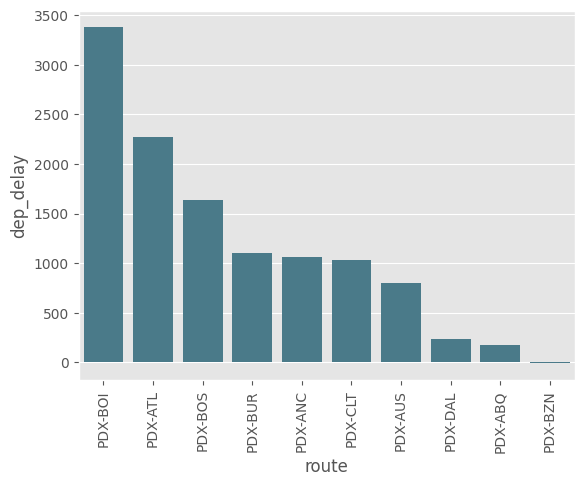

In [119]:
routes = df.groupby("route")["dep_delay"].sum().reset_index().head(10)
_ = custom_barplot(routes,"route","dep_delay",sum)

## Additional Operations

**Adding Number of Aircraft**

- The number of aircraft per airline was calculated by counting the unique tail numbers.  
- The airline with the most aircraft is Southwest Airlines Co., while the airline with the fewest aircraft is Allegiant Air. The ranked list and visualization are provided below.  
- The aircraft counts were also added to the dataset as a categorical variable.


In [120]:
df.groupby("airline")["tailnum"].nunique().reset_index().sort_values("tailnum",ascending=False)

,airline,tailnum
9,Southwest Airlines Co.,728
2,American Airlines Inc.,612
3,Delta Air Lines Inc.,610
11,United Air Lines Inc.,525
8,SkyWest Airlines Inc.,272
0,Alaska Airlines Inc.,228
7,JetBlue Airways,157
10,Spirit Air Lines,120
4,Frontier Airlines Inc.,108
6,Horizon Air,61


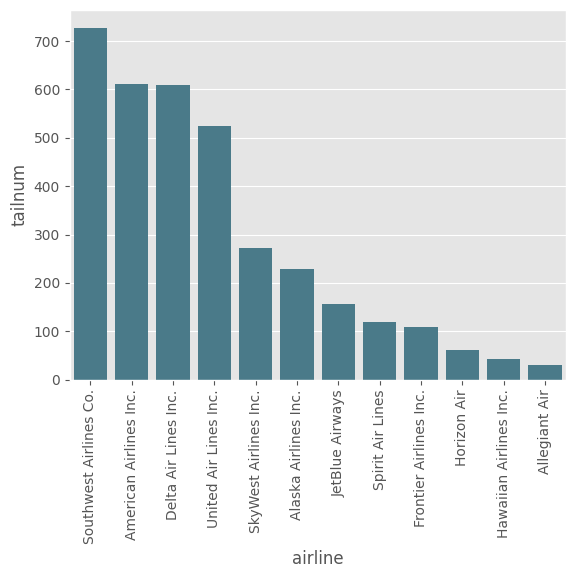

In [121]:
airline_total_aircraft_count = df.groupby("airline")["tailnum"].nunique().reset_index()
_ = custom_barplot(airline_total_aircraft_count,"airline","tailnum",sum)

- Adding the number of aircraft to the dataset.


In [122]:
airline_total_aircraft_count = df.groupby("airline")["tailnum"].nunique()
df["aircraft_count_by_airline"] = df["airline"].map(airline_total_aircraft_count)

In [123]:
df.groupby("airline")["aircraft_count_by_airline"].mean().reset_index()

,airline,aircraft_count_by_airline
0,Alaska Airlines Inc.,228.0
1,Allegiant Air,30.0
2,American Airlines Inc.,612.0
3,Delta Air Lines Inc.,610.0
4,Frontier Airlines Inc.,108.0
5,Hawaiian Airlines Inc.,42.0
6,Horizon Air,61.0
7,JetBlue Airways,157.0
8,SkyWest Airlines Inc.,272.0
9,Southwest Airlines Co.,728.0


## Correlation Analysis

- Our target variable is `dep_delay`. The analysis investigates whether there is a correlation between this variable and other numerical variables.  
- Before the analysis, columns created for control or calculation purposes were removed.

In [135]:

columns_to_be_remove = ["date_string","hour_check_dep","hour_check_sched"]
df.drop(columns_to_be_remove, axis=1, inplace=True)
df.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'airline', 'route', 'temp', 'dewp', 'humid', 'wind_dir', 'wind_speed',
       'wind_gust', 'precip', 'pressure', 'visib', 'date',
       'distance_ratio_by_total', 'distance_category', 'daily_flight_count',
       'airline_daily_performance_kpi', 'aircraft_count_by_airline',
       'dep_delay_category'],
      dtype='object')



**Heatmap Analysis and Identification of Highly Correlated Variables**


Variables with a correlation above 70% were removed to prevent multicollinearity issues.  
Highly correlated features can mislead machine learning models, as they often represent the same information with minor differences.

The following features were excluded based on high correlation:

- **arr_delay - dep_delay**: Correlation of **0.92**. Since `dep_delay` is the target variable, only `arr_delay` may be used as a feature.
- **distance - air_time**: Correlation of **0.99**, which is extremely high. `air_time` will not be used in the model.
- **flight - distance_ratio_by_total**: A **-0.70** strong negative correlation. `flight` will be excluded due to its high cardinality and correlation.
- **temp - dewp**: Dew point (`dewp`) is highly correlated with temperature (`temp`) with a **0.75** correlation. Therefore, `dewp` will not be used.
- **wind_speed - wind_gust**: Perfect correlation of **1.0**. As they represent the same information, `wind_gust` will be excluded.
- **distance_ratio_by_total - daily_flight_count**: Correlation of **0.92**. `daily_flight_count` will not be used.

Other positive and negative correlations can be observed in the correlation matrix table.

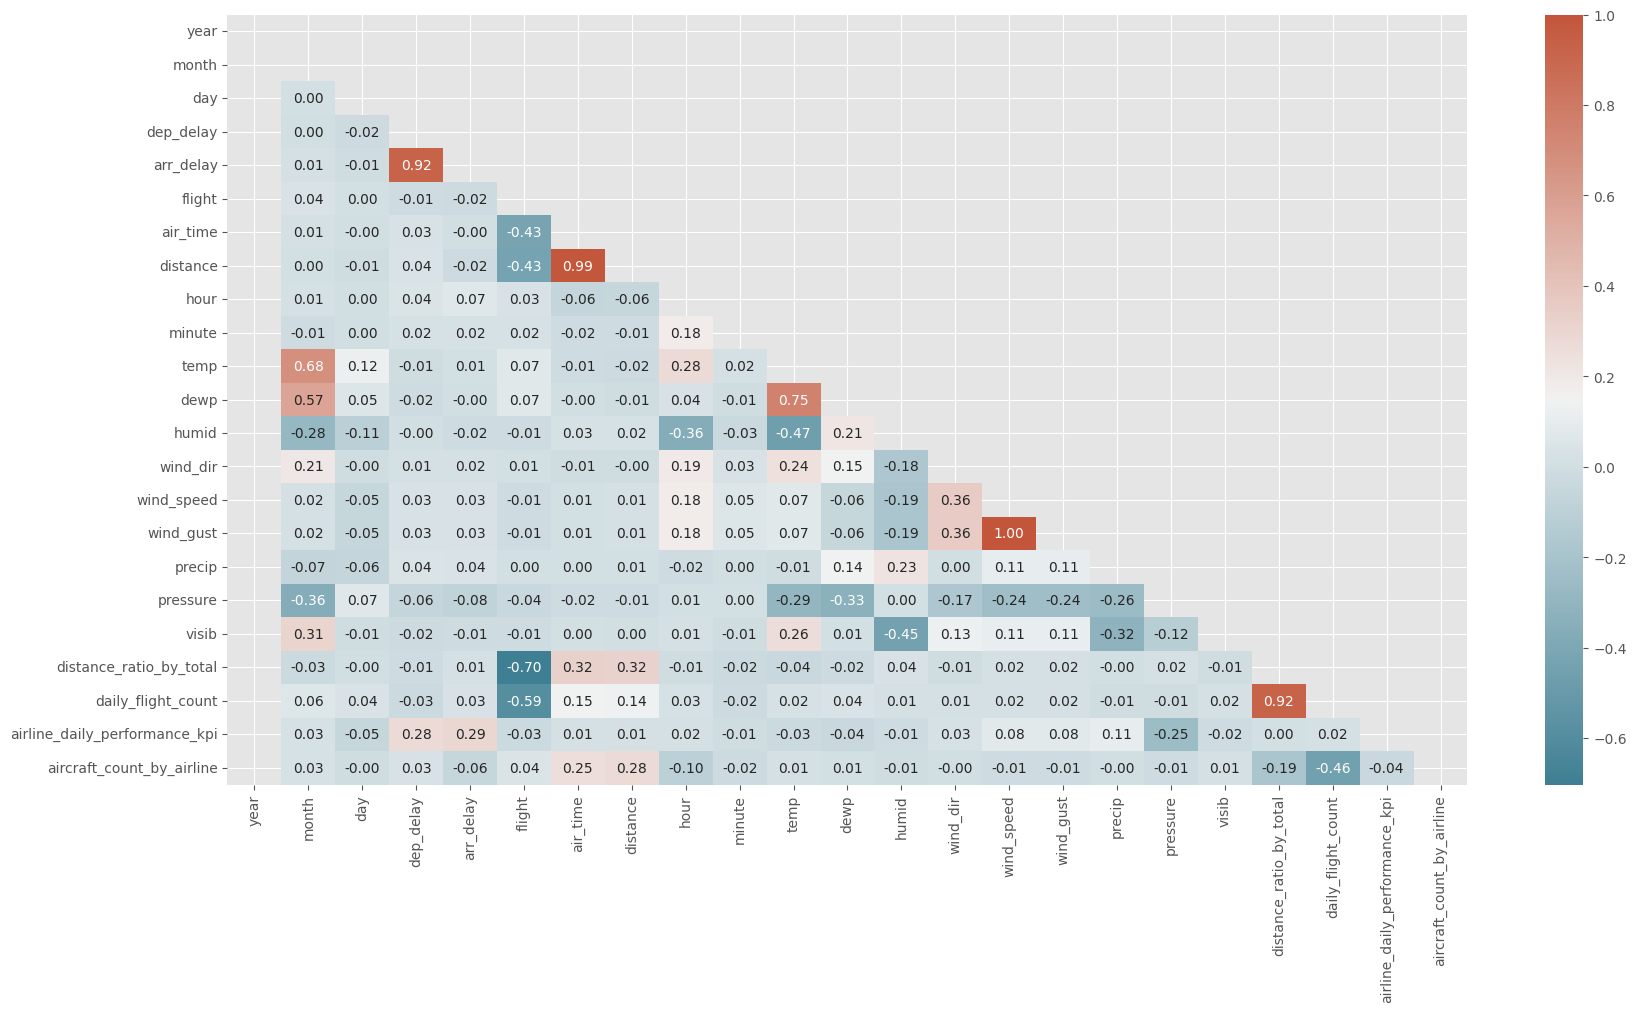

In [136]:
plt.figure(figsize=(20, 10))
num_variables = df.select_dtypes(include=["float64","int64"])
corr_df = num_variables.corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))
tri_df = corr_df.mask(mask)
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(tri_df,annot=True,fmt=".2f",cmap = cmap)
plt.show()

**Correlation of the Target Variable (`dep_delay`) with Other Features**

- In this section, the correlation between the target variable `dep_delay` and numerical features has been analyzed.
- A correlation threshold of **0.03** has been set, and the results have been visualized accordingly.
- First, variables that are highly correlated with each other were removed to avoid multicollinearity. Then, the number of features with a correlation above the threshold with the target variable was determined.
- As a result, **8 features** were found to have a correlation higher than 0.03 with `dep_delay`.
- The `airline_daily_performance_kpi` features we created showed strong correlation with `arr_delay`.
- Additionally, there is a slight correlation between the `precip` variable (which represents total precipitation from weather data) and `dep_delay`, suggesting that **precipitation may have an impact on flight delays**.


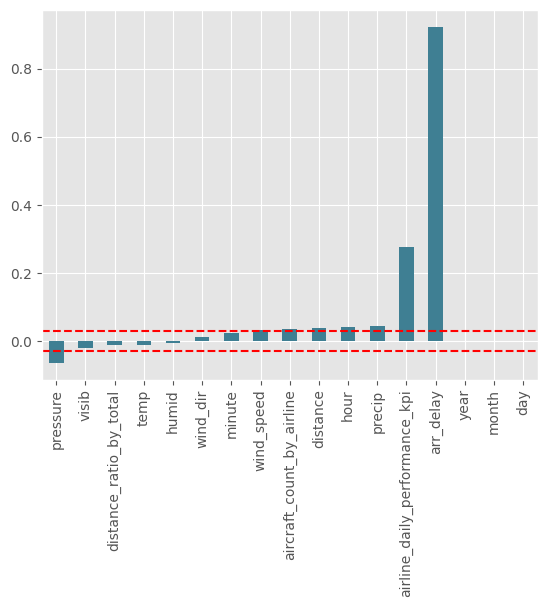

In [137]:
corrs_that_will_not_be_used = ["air_time","flight","dewp","wind_gust","daily_flight_count","dep_delay"]
tri_df["dep_delay"].drop(corrs_that_will_not_be_used).sort_values().plot(kind="bar")
plt.axhline(0.03, color ="red",linestyle ='--')
plt.axhline(-0.03, color='red',linestyle='--')
plt.show()

In [138]:
corrs_that_will_be_drop = ["air_time","flight","dewp","wind_gust","daily_flight_count"]
cor_target = abs(tri_df["dep_delay"])
cor_target.drop(corrs_that_will_be_drop,inplace=True,axis=0)
correlated_features  = cor_target[cor_target >=0.03]
print("Total features:",len(df.select_dtypes(include=["float64","int64"]).columns))
print("Correlated features:",len(correlated_features))

Total features: 23
Correlated features: 8


## Data Preprocessing

**Operations to be applied to variables before modeling:**
1. Unnecessary variables are identified and removed.
2. Ordinal categorical variables are selected for label encoding.
3. Nominal categorical variables are selected for one-hot encoding.

### 1. Identifying Unused Variables
- Variables with low correlation to the target variable based on correlation analysis are excluded.
- Categorical variables with high cardinality are excluded to avoid the curse of dimensionality, which can increase the risk of overfitting.
- Numerical variables with very high cardinality are also excluded.
- Datetime variables are not used directly.
- Variables that express the same information are excluded to avoid redundancy.


In [139]:

corrs = ["air_time","flight","dewp","wind_gust","daily_flight_count"]

In [140]:
cat_with_high_card = [col for col in df.columns if df[col].nunique() > 80 and str(df[col].dtypes) in ["category", "object"]]
cat_with_high_card

['tailnum', 'dest', 'route']

In [141]:

df["flight"].nunique()

1099

In [142]:
date_features = df.select_dtypes(include="datetime64").columns.to_list()
date_features

['dep_time', 'sched_dep_time', 'arr_time', 'sched_arr_time', 'date']

In [143]:
other_features = ["carrier","origin"]

In [144]:
cols_will_be_not_used = corrs + cat_with_high_card + date_features + other_features
cols_will_be_not_used

['air_time',
 'flight',
 'dewp',
 'wind_gust',
 'daily_flight_count',
 'tailnum',
 'dest',
 'route',
 'dep_time',
 'sched_dep_time',
 'arr_time',
 'sched_arr_time',
 'date',
 'carrier',
 'origin']

In [145]:
feature_columns = [col for col in df.columns if col not in cols_will_be_not_used]
df = df[feature_columns]
df.head()

,year,month,day,dep_delay,arr_delay,distance,hour,minute,airline,temp,humid,wind_dir,wind_speed,precip,pressure,visib,distance_ratio_by_total,distance_category,airline_daily_performance_kpi,aircraft_count_by_airline,dep_delay_category
0,2022,1,1,21.0,6.0,2724,0,43,American Airlines Inc.,25.0,62.50,350.0,8.05546,0.0,1020.7,10.0,0.051758,1000+ miles,17.631579,612,Level 5
1,2022,1,1,8.0,6.0,1024,5,5,United Air Lines Inc.,24.1,74.27,110.0,6.90468,0.0,1023.0,10.0,0.073424,1000+ miles,25.884615,525,Level 5
2,2022,1,1,-1.0,-14.0,1009,5,15,Southwest Airlines Co.,28.0,57.93,130.0,9.20624,0.0,1023.1,10.0,0.051165,1000+ miles,43.459459,728,Level 3
3,2022,1,1,-3.0,-21.0,1751,5,35,Southwest Airlines Co.,28.0,57.93,130.0,9.20624,0.0,1023.1,10.0,0.051165,1000+ miles,43.459459,728,Level 3
4,2022,1,1,12.0,-1.0,672,5,25,Southwest Airlines Co.,24.1,74.27,110.0,6.90468,0.0,1023.0,10.0,0.051165,500-1000 miles,43.459459,728,Level 5


**2. Label Encoding**

- The variables `distance_category` and `dep_delay_category` are ordinal categorical variables that represent increasing magnitude. 
- Therefore, label encoding was applied.
- First, the data type of these variables was converted to ordered categorical types. 
- Then, label encoding was performed accordingly.


In [146]:
df["distance_category"].value_counts()

distance_category
1000+ miles       42737
500-1000 miles    37836
0-500 miles       25041
Name: count, dtype: int64

In [147]:
df["distance_category"].dtype

CategoricalDtype(categories=['0-500 miles', '500-1000 miles', '1000+ miles'], ordered=True, categories_dtype=object)

In [148]:
df["distance_category"] = df["distance_category"].cat.codes
df["distance_category"].value_counts()

distance_category
2    42737
1    37836
0    25041
Name: count, dtype: int64

**3. One Hot Encoding**
- The `airline` variable represents 12 distinct airline companies, so it is considered a nominal categorical variable.
- Therefore, one-hot encoding was applied.
- It is important to avoid the **dummy trap** when applying one-hot encoding.  
  The dummy trap occurs when dummy variables created during one-hot encoding are linearly dependent. For example, if one category is not explicitly represented, its value can be inferred from the others. This can reduce the model's accuracy and performance.  
- To prevent the dummy trap, it is common to use the `drop_first` parameter to drop one dummy variable. This helps the model produce more balanced and reliable results.
- After one-hot encoding, the original categorical variable was removed.


In [152]:
category_one_hot = pd.get_dummies(df["airline"],drop_first=True).astype(int)
df.drop("airline", axis=1,inplace=True)
df=pd.concat([df,category_one_hot], axis=1)
df.head()

,year,month,day,dep_delay,arr_delay,distance,hour,minute,temp,humid,wind_dir,wind_speed,precip,pressure,visib,distance_ratio_by_total,distance_category,airline_daily_performance_kpi,aircraft_count_by_airline,dep_delay_category,Allegiant Air,American Airlines Inc.,Delta Air Lines Inc.,Frontier Airlines Inc.,Hawaiian Airlines Inc.,Horizon Air,JetBlue Airways,SkyWest Airlines Inc.,Southwest Airlines Co.,Spirit Air Lines,United Air Lines Inc.
0,2022,1,1,21.0,6.0,2724,0,43,25.0,62.50,350.0,8.05546,0.0,1020.7,10.0,0.051758,2,17.631579,612,4,0,1,0,0,0,0,0,0,0,0,0
1,2022,1,1,8.0,6.0,1024,5,5,24.1,74.27,110.0,6.90468,0.0,1023.0,10.0,0.073424,2,25.884615,525,4,0,0,0,0,0,0,0,0,0,0,1
2,2022,1,1,-1.0,-14.0,1009,5,15,28.0,57.93,130.0,9.20624,0.0,1023.1,10.0,0.051165,2,43.459459,728,2,0,0,0,0,0,0,0,0,1,0,0
3,2022,1,1,-3.0,-21.0,1751,5,35,28.0,57.93,130.0,9.20624,0.0,1023.1,10.0,0.051165,2,43.459459,728,2,0,0,0,0,0,0,0,0,1,0,0
4,2022,1,1,12.0,-1.0,672,5,25,24.1,74.27,110.0,6.90468,0.0,1023.0,10.0,0.051165,1,43.459459,728,4,0,0,0,0,0,0,0,0,1,0,0


## Model Building and Evaluation

- Predicting the continuous target variable `dep_delay` is a regression problem.
- The chosen model is XGBoostRegressor. This model is one of the boosting ensemble learning methods. Its base learners are decision trees. It combines many weak decision trees that learn from each other's errors and improve over iterations. It is frequently used for capturing complex relationships.
- XGBoost does not require feature scaling and is known for its fast performance.
- The evaluation metrics selected are Root Mean Squared Error (RMSE) and R² score.
- RMSE was chosen because the result is in the same unit as the predicted variable, making it easier to interpret and compare. It is the square root of the average of the squared differences between actual and predicted values.

**Definition of the function to be used for model training and evaluation**

In [153]:
def train_with_cv(model, X_train, y_train, cv_splits=10):
    train_scores = []
    val_scores = []
    fold = 1
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred_tr = model.predict(X_tr)
        y_pred_val = model.predict(X_val)

        train_rmse = np.sqrt(np.mean((y_tr - y_pred_tr) ** 2))
        val_rmse = np.sqrt(np.mean((y_val - y_pred_val) ** 2))

        print(f"Fold {fold}: train_RMSE = {train_rmse:.3f}, val_RMSE = {val_rmse:.3f}")

        train_scores.append(train_rmse)
        val_scores.append(val_rmse)
        fold += 1
    
    avg_train_rmse = np.mean(train_scores)
    avg_val_rmse = np.mean(val_scores)
    print("===================================")
    print(f"Average train_RMSE: {avg_train_rmse:.3f}")
    print(f"Average validation_RMSE: {avg_val_rmse:.3f}")
    print("===================================")

    scores_df = pd.DataFrame({
        "fold": range(1, fold),
        "train_RMSE": train_scores,
        "validation_RMSE": val_scores
    })

    return scores_df

def train_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    print("Model training completed.")
    return model


def evaluate(model, X_test, y_test):
    y_pred_test = model.predict(X_test)
    test_rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
    print(f"Test RMSE: {test_rmse:.3f}")

    return test_rmse, y_pred_test


def predict_single(model, X_single):

    if isinstance(X_single, pd.Series):
        X_single = X_single.to_frame().T
    elif isinstance(X_single, dict):
        X_single = pd.DataFrame([X_single])

    prediction = model.predict(X_single)
    return prediction[0]  



**Splitting Data into Training and Test Sets**  
- It is common practice to split the dataset into training and test sets to calculate metrics during the modeling phase.  
- Here, 20% of the data is set aside as the test set.

In [154]:
target = "dep_delay"
X = df.drop(target,axis=1)
y= df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

In [155]:
X_train.shape

(84491, 30)

In [156]:
y_train.shape

(84491,)

In [157]:
X_test.shape

(21123, 30)

In [158]:
y_test.shape

(21123,)

**XgBoostRegressor**
- Since the model is tree-based, it performs well on complex and skewed data.  
  Therefore, no feature scaling has been applied.


**XGBoostRegressor Hyperparameter Tuning**

- Therefore, Bayesian hyperparameter tuning was preferred in this problem.
- Bayesian hyperparameter tuning uses Bayesian statistics to optimize hyperparameters in machine learning models.
  This method updates a probability distribution to predict the best hyperparameter values and aims to improve model performance.
- At each step, it uses the results from previous trials to choose the most promising parameter combinations for new trials. This provides a smarter search strategy.
- By considering the parameter ranges and the knowledge from prior experiments, it can search more efficiently.
- The goal is to select the most performance-impacting parameters of XGBoost to provide an overall view.
- `learning_rate` defines the step size in the gradient descent method.
- `n_estimators` is the number of trees to be used.
- `max_depth` determines how deep the tree will go, or in other words, how many nodes it will have.
- `booster` defines whether the base learner is a tree or a linear model.
- `seed` sets the initial value for the model's random number generation.
- `colsample_bytree` refers to the percentage of features to be used for each tree. For example, a value of 0.8 means 80% of the features will be used in the model.
- `alpha` represents L1 (Lasso) regularization. A higher value applies stronger regularization, simplifying the model.



In [1058]:

space = {
    "learning_rate": hp.loguniform("learning_rate", np.log(0.04), np.log(0.1)),  
    "n_estimators": hp.quniform("n_estimators", 50, 300, 1),  
    "max_depth": hp.quniform("max_depth", 1, 10, 1),  
    'booster': hp.choice('booster', ['gbtree', 'gblinear']), 
    'seed': 0,
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),  
    'alpha': hp.uniform('alpha', 0, 1) 
}

def objective(params,X,y):
    xg_reg = XGBRegressor(
        n_estimators=int(params["n_estimators"]),
        max_depth=int(params["max_depth"]),
        learning_rate=params["learning_rate"],
        seed=params['seed'],
        booster=params['booster'],
        colsample_bytree=params['colsample_bytree'], 
        alpha=params['alpha'] 
    )
    
    kf = KFold(n_splits=10,shuffle=True,random_state=42)
    rmse_scores = []
 
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        xg_reg.fit(X_train, y_train)
        predictions = xg_reg.predict(X_test)

        mse_score = mean_squared_error(y_test, predictions)
        rmse_score = np.sqrt(mse_score)
        rmse_scores.append(rmse_score)

    average_rmse = sum(rmse_scores) / len(rmse_scores)
    return average_rmse


trials = Trials()
best = fmin(fn=lambda params:objective(params,X=X,y=y), space=space, algo=tpe.suggest, max_evals=80, trials=trials)

print("Best hyperparameters:", best)
print("Best score (MAE):", trials.best_trial["result"]["loss"])


100%|██████████| 80/80 [17:02<00:00, 12.78s/trial, best loss: 8.272284216344005]
Best hyperparameters: {'alpha': 0.011812343088790311, 'booster': 0, 'colsample_bytree': 0.7658763597487106, 'learning_rate': 0.09649784160768939, 'max_depth': 3.0, 'n_estimators': 250.0}
Best score (MAE): 8.272284216344005


In [159]:
bayesian_xgb_params = {'alpha': 0.7, 'booster': 'gbtree', 'colsample_bytree': 0.9, 'learning_rate': 0.09, 'max_depth': 2, 'n_estimators': 250}

In [160]:
import json

bayesian_xgb_params = {
    'alpha': 0.7,
    'booster': 'gbtree',
    'colsample_bytree': 0.9,
    'learning_rate': 0.09,
    'max_depth': 2,
    'n_estimators': 250
}

with open('data/hyperparameters.json', 'w') as f:
    json.dump(bayesian_xgb_params, f, indent=4)


In [161]:
xgb = XGBRegressor(**bayesian_xgb_params,n_jobs=-1)
xgb.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': 'gbtree',
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.9,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.09,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 2,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 250,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'alpha': 0.7}

In [162]:
scores_df = train_with_cv(xgb, X_train, y_train, cv_splits=10)
trained_model = train_model(xgb, X_train, y_train)
test_rmse, y_pred_test = evaluate(trained_model, X_test, y_test)

Fold 1: train_RMSE = 8.191, val_RMSE = 8.699
Fold 2: train_RMSE = 7.921, val_RMSE = 11.176
Fold 3: train_RMSE = 8.261, val_RMSE = 7.679
Fold 4: train_RMSE = 8.276, val_RMSE = 7.457
Fold 5: train_RMSE = 8.095, val_RMSE = 9.774
Fold 6: train_RMSE = 7.951, val_RMSE = 8.343
Fold 7: train_RMSE = 8.219, val_RMSE = 7.839
Fold 8: train_RMSE = 8.258, val_RMSE = 7.376
Fold 9: train_RMSE = 8.271, val_RMSE = 7.941
Fold 10: train_RMSE = 8.146, val_RMSE = 9.014
Average train_RMSE: 8.159
Average validation_RMSE: 8.530
Model training completed.
Test RMSE: 8.766


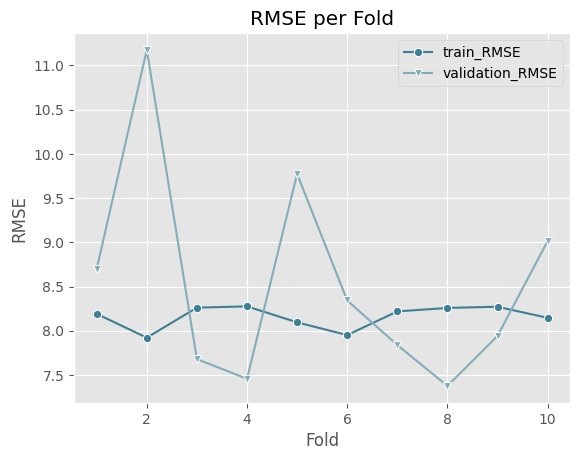

In [163]:
sns.lineplot(data=scores_df, x="fold", y="train_RMSE", marker="o", label="train_RMSE")
sns.lineplot(data=scores_df, x="fold", y="validation_RMSE", marker="v", label="validation_RMSE")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("RMSE per Fold")
plt.legend()
plt.show()


**XGBoost Regressor Feature Importance Analysis**

- Feature importances were extracted from the trained model using the `feature_importances_` attribute.
- A visualization was created to illustrate which features contributed most to the model's predictions.
- The most influential features were identified as:
  - `arr_delay`
  - `hour`
  - `airline_daily_performance_kpi`
  - `aircraft_count_by_airline`
  - `dep_delay_category`


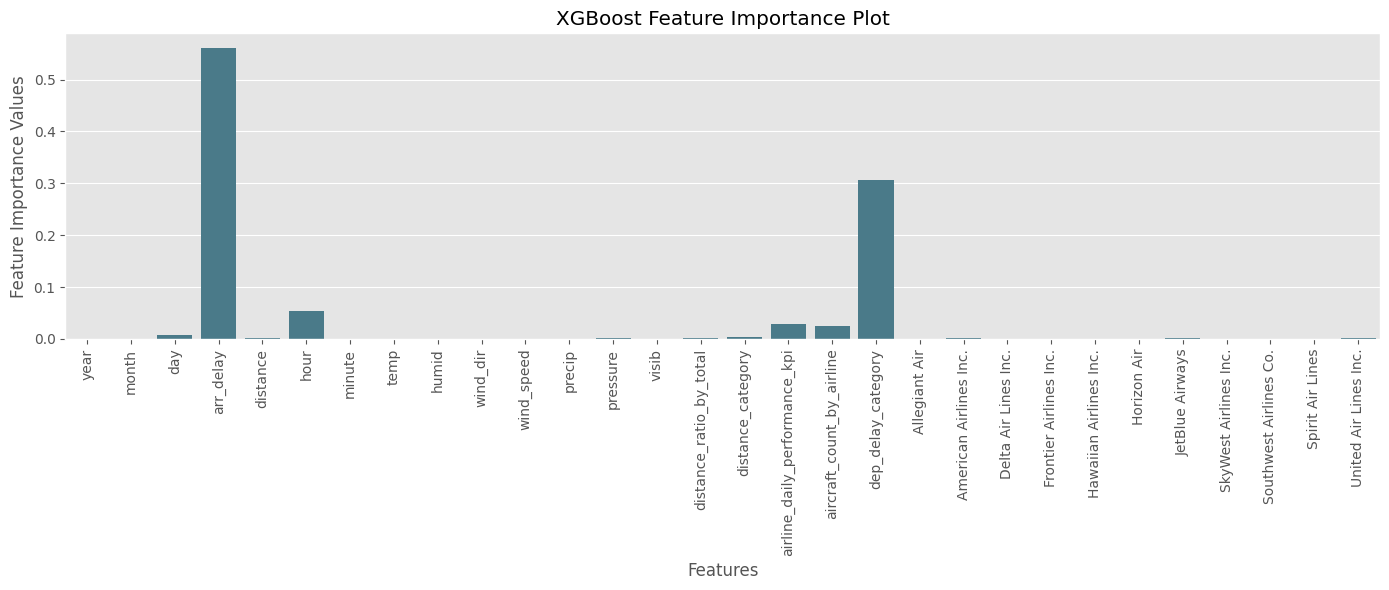

In [164]:
feature_importances = xgb.feature_importances_
columns = X_train.columns

plt.figure(figsize=(14, 6))
sns.barplot(x=columns, y=feature_importances)

plt.xlabel("Features")
plt.ylabel("Feature Importance Values")
plt.title("XGBoost Feature Importance Plot")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Prediction

In [165]:
single_sample = X_test.iloc[100]
pred = predict_single(trained_model, single_sample)
print(f"Prediction for single sample: {pred:.3f}")


Prediction for single sample: 16.129
